# GRU Regressor

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src.visualization import evaluate_and_plot_full_forecast
from src.models.rnn.rnn_regressor import RNNRegressor
from src.models.rnn.train_rnn_recursive import train_rnn_recursive
from src.models.rnn.predict import predict_recursive
from src.models.rnn.data_preparing import create_sequences
from src.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
set_seed(SEED)

In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
borehole_name = '48-1'
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
features_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [6]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [7]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [8]:
target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [9]:
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size, shuffle=False)

In [10]:
val_future_features_tensor = torch.tensor(
    val_scaled[lags_length:, :len(features_cols)], 
    dtype=torch.float32
).to(device)

input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    set_seed(SEED + trial.number)
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 2, 5)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    model_trial = RNNRegressor(
        input_size,
        hidden_size,
        num_layers,
        output_size,
        dropout=dropout,
        rnn_type='gru'
    ).to(device)
    optimizer_trial = optim.AdamW(model_trial.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    model_trial, history = train_rnn_recursive(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        val_future_features=val_future_features_tensor,
        reg_type='l1',
        scheduler=scheduler,
        epochs=100,
        max_epochs_no_improvement=20,
        device=device,
        verbose=False
    )
    
    trial.set_user_attr('best_epoch', history['best_epoch'])
    trial.set_user_attr('total_epochs', len(history['val_rmse']))
    
    best_val_rmse = float(history['best_val_rmse'][-1])
    return best_val_rmse

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=20)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-11 01:56:55,805] A new study created in memory with name: no-name-1b8569a5-0ec2-4385-85b0-57935242d031
[I 2026-06-11 01:57:16,409] Trial 0 finished with value: 0.283433735370636 and parameters: {'hidden_size': 64, 'num_layers': 5, 'dropout': 0.39279757672456206, 'lr': 0.00015751320499779721, 'weight_decay': 2.9380279387035354e-06}. Best is trial 0 with value: 0.283433735370636.


Early stopping on 50 epoch


[I 2026-06-11 01:57:43,273] Trial 1 finished with value: 0.2828370928764343 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.4464704583099741, 'lr': 0.00015930522616241006, 'weight_decay': 0.000133112160807369}. Best is trial 1 with value: 0.2828370928764343.
[I 2026-06-11 01:58:17,291] Trial 2 finished with value: 0.6503031253814697 and parameters: {'hidden_size': 16, 'num_layers': 5, 'dropout': 0.4329770563201687, 'lr': 2.6587543983272695e-05, 'weight_decay': 3.5113563139704077e-06}. Best is trial 1 with value: 0.2828370928764343.
[I 2026-06-11 01:58:27,270] Trial 3 finished with value: 0.9217576384544373 and parameters: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.3099025726528951, 'lr': 7.309539835912905e-05, 'weight_decay': 7.4763120622522945e-06}. Best is trial 1 with value: 0.2828370928764343.


Early stopping on 32 epoch


[I 2026-06-11 01:58:55,758] Trial 4 finished with value: 0.24852409958839417 and parameters: {'hidden_size': 112, 'num_layers': 2, 'dropout': 0.21685785941408728, 'lr': 5.4041038546473305e-05, 'weight_decay': 2.334586407601622e-05}. Best is trial 4 with value: 0.24852409958839417.
[I 2026-06-11 01:59:15,207] Trial 5 finished with value: 0.2189069390296936 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3056937753654446, 'lr': 0.00015304852121831474, 'weight_decay': 1.3783237455007196e-06}. Best is trial 5 with value: 0.2189069390296936.


...

Early stopping on 33 epoch


[I 2026-06-11 02:03:24,121] Trial 16 finished with value: 0.21780207753181458 and parameters: {'hidden_size': 144, 'num_layers': 4, 'dropout': 0.26906172490646174, 'lr': 0.00022477923713281752, 'weight_decay': 0.00011606159532098588}. Best is trial 16 with value: 0.21780207753181458.


Early stopping on 58 epoch


[I 2026-06-11 02:03:56,010] Trial 17 finished with value: 0.246001198887825 and parameters: {'hidden_size': 80, 'num_layers': 4, 'dropout': 0.2681090679764574, 'lr': 3.0845007496515616e-05, 'weight_decay': 0.0002218395598539011}. Best is trial 16 with value: 0.21780207753181458.
[I 2026-06-11 02:04:30,155] Trial 18 finished with value: 0.2588179111480713 and parameters: {'hidden_size': 96, 'num_layers': 4, 'dropout': 0.17628891169343233, 'lr': 8.55004739061237e-05, 'weight_decay': 5.217724609760876e-05}. Best is trial 16 with value: 0.21780207753181458.
[I 2026-06-11 02:04:46,750] Trial 19 finished with value: 0.353379487991333 and parameters: {'hidden_size': 144, 'num_layers': 5, 'dropout': 0.2691976210488023, 'lr': 0.00019096036038607336, 'weight_decay': 0.0002778244006002339}. Best is trial 16 with value: 0.21780207753181458.


Early stopping on 36 epoch
Лучшие параметры:  {'hidden_size': 144, 'num_layers': 4, 'dropout': 0.26906172490646174, 'lr': 0.00022477923713281752, 'weight_decay': 0.00011606159532098588}
Количество эпох в лучшем запуске:  59


In [18]:
#input_size = full_train_scaled.shape[1]
set_seed(SEED)
model = RNNRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size,
    dropout=study.best_params['dropout'],
    rnn_type='gru'
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

model, _ = train_rnn_recursive(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    reg_type='l1',
    scheduler=scheduler,
    epochs=study.best_trial.user_attrs['best_epoch'],
    max_epochs_no_improvement=20,
    device=device,
    verbose=True
)

Epoch 1/39 | Train Loss: 18.9961
Epoch 2/39 | Train Loss: 17.1270
Epoch 3/39 | Train Loss: 15.4147
Epoch 4/39 | Train Loss: 13.9673
Epoch 5/39 | Train Loss: 12.6375
Epoch 6/39 | Train Loss: 11.3745
Epoch 7/39 | Train Loss: 10.1867
Epoch 8/39 | Train Loss: 9.0685
Epoch 9/39 | Train Loss: 8.0236
Epoch 10/39 | Train Loss: 7.0533
Epoch 11/39 | Train Loss: 6.1627
Epoch 12/39 | Train Loss: 5.3495
Epoch 13/39 | Train Loss: 4.6099
Epoch 14/39 | Train Loss: 3.9448
Epoch 15/39 | Train Loss: 3.3531
Epoch 16/39 | Train Loss: 2.8344
Epoch 17/39 | Train Loss: 2.3913
Epoch 18/39 | Train Loss: 2.0217
Epoch 19/39 | Train Loss: 1.7257
Epoch 20/39 | Train Loss: 1.5033
Epoch 21/39 | Train Loss: 1.3529
Epoch 22/39 | Train Loss: 1.2495
Epoch 23/39 | Train Loss: 1.1661
Epoch 24/39 | Train Loss: 1.0940
Epoch 25/39 | Train Loss: 1.0296
Epoch 26/39 | Train Loss: 0.9748
Epoch 27/39 | Train Loss: 0.9272
Epoch 28/39 | Train Loss: 0.8817
Epoch 29/39 | Train Loss: 0.8416
Epoch 30/39 | Train Loss: 0.8069
Epoch 31/39 

In [10]:
model_path = 'models/gru_v1.pth'
weights_path = 'models/gru_v1_weights.pth'

# torch.save(model, model_path)
# torch.save(model.state_dict(), weights_path)

model = torch.load(model_path, weights_only=False)

                              RMSE       MAE        ME       NSE
Значение для всех глубин  1.014435  0.797684 -0.092433  0.896914


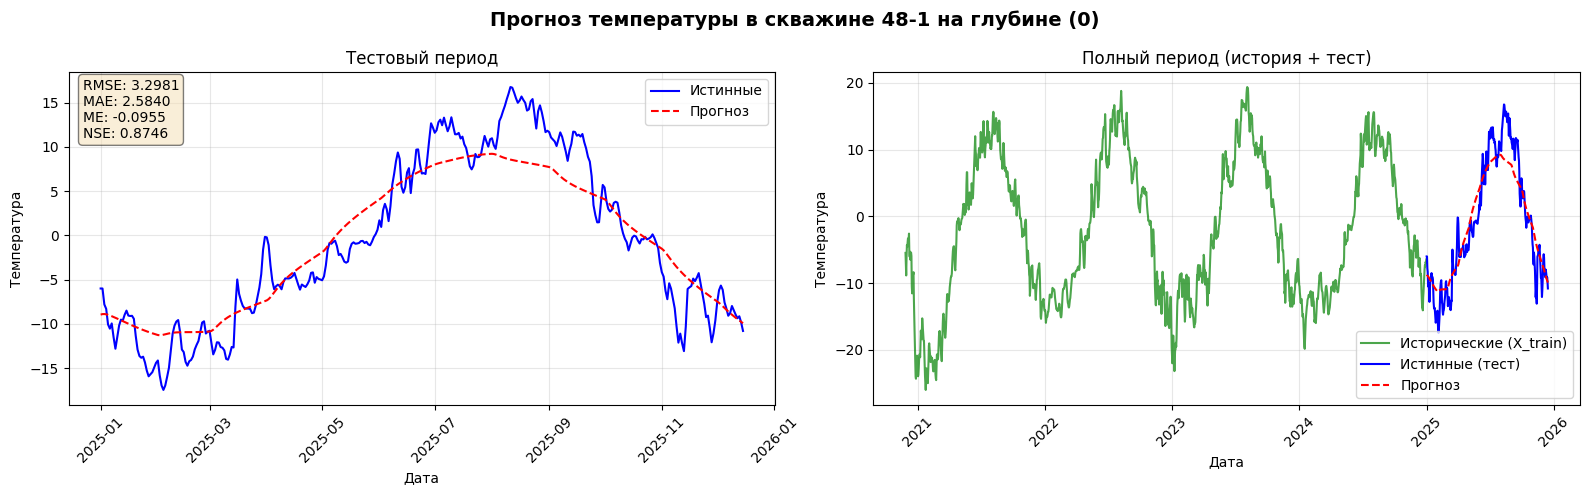

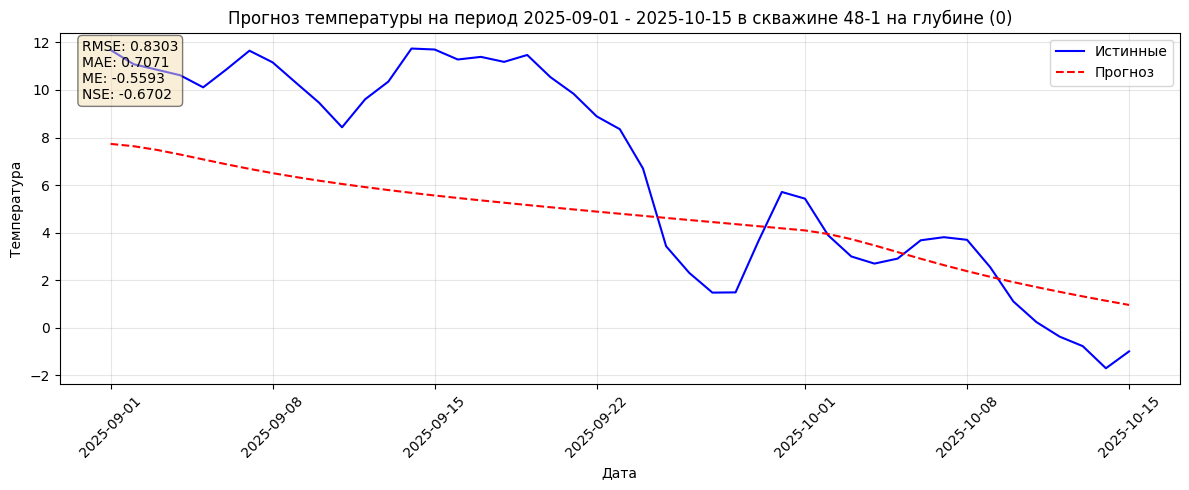

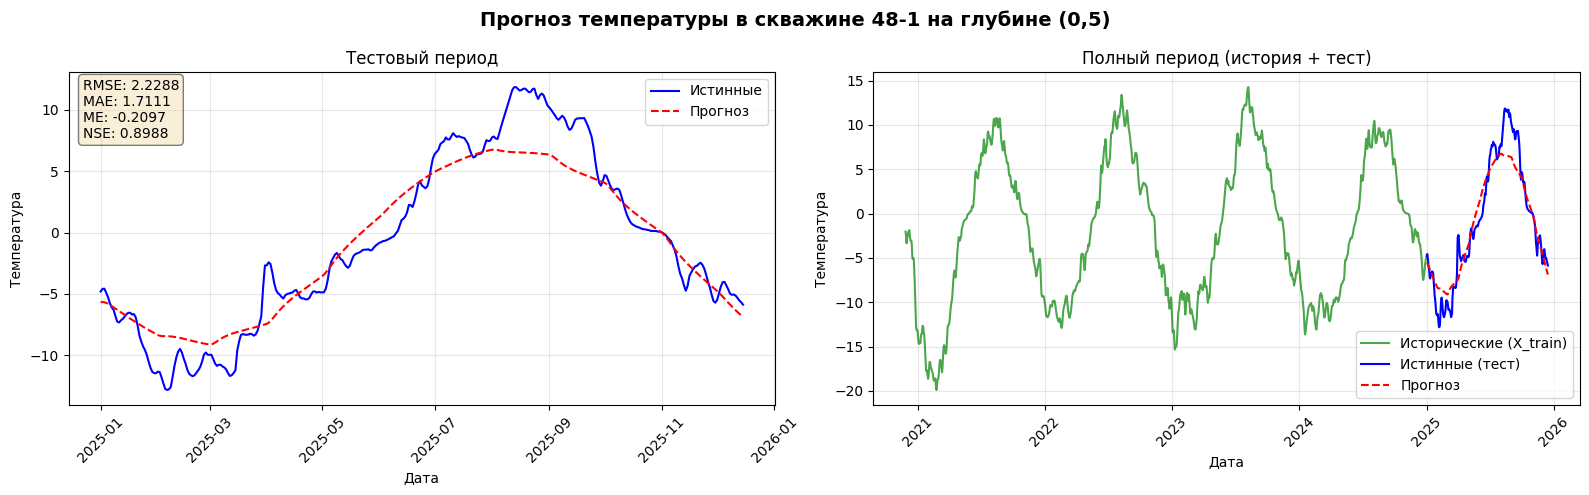

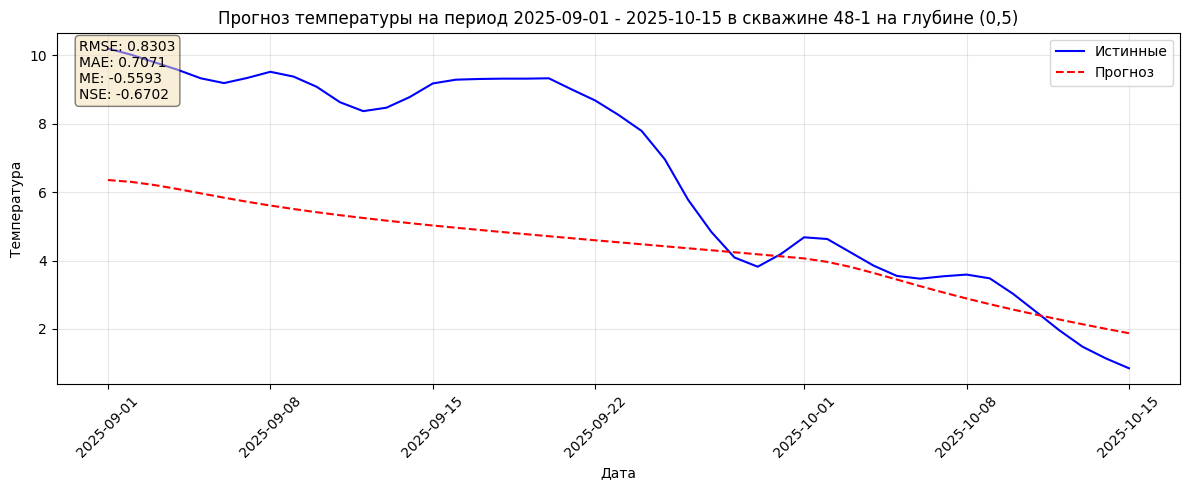

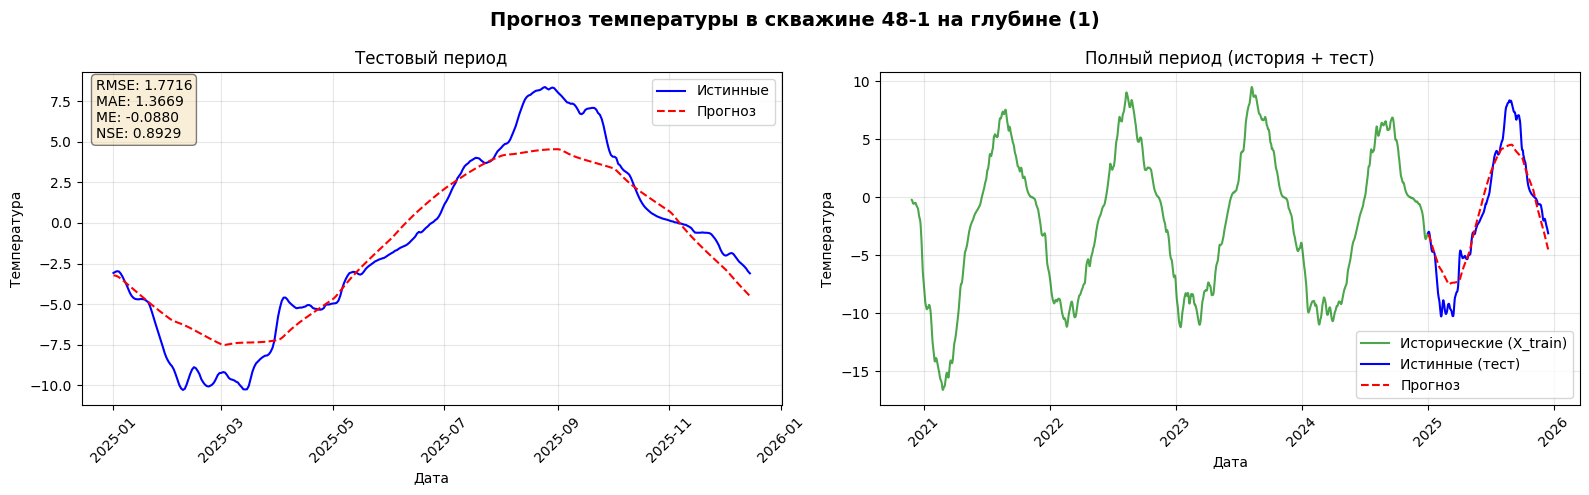

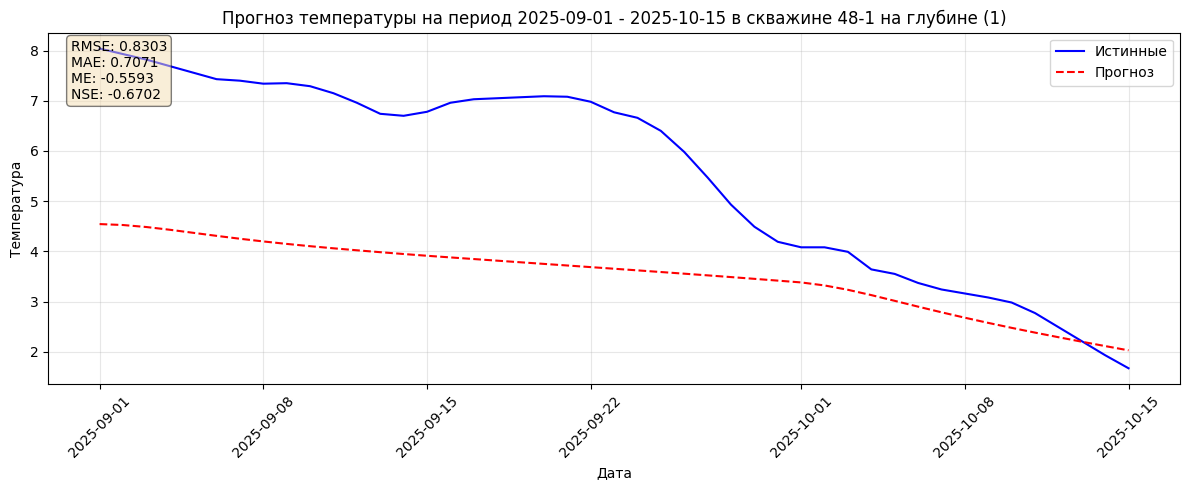

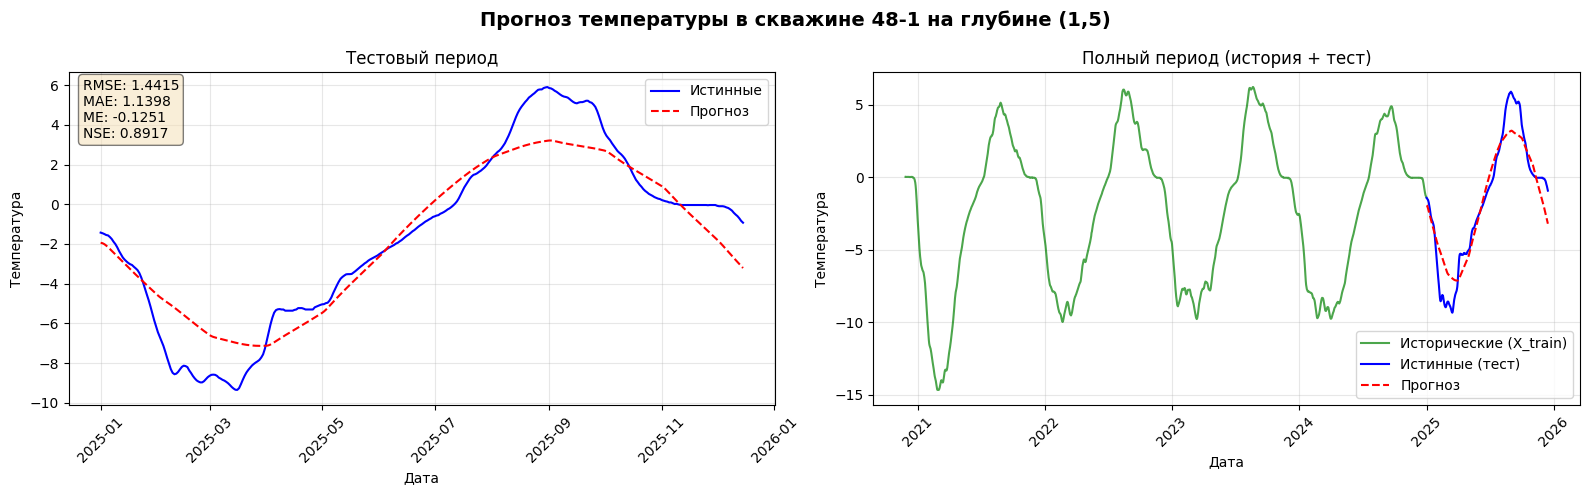

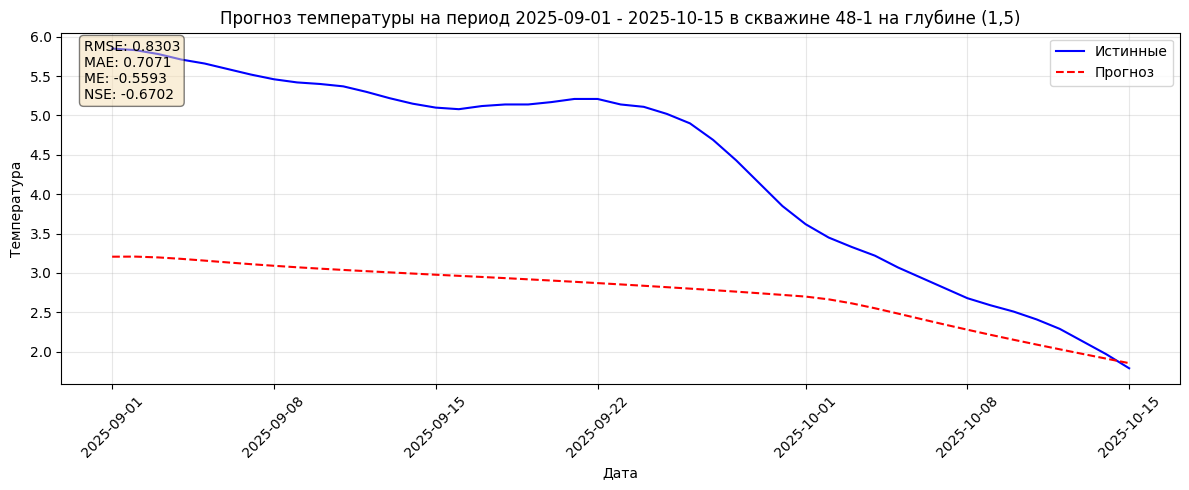

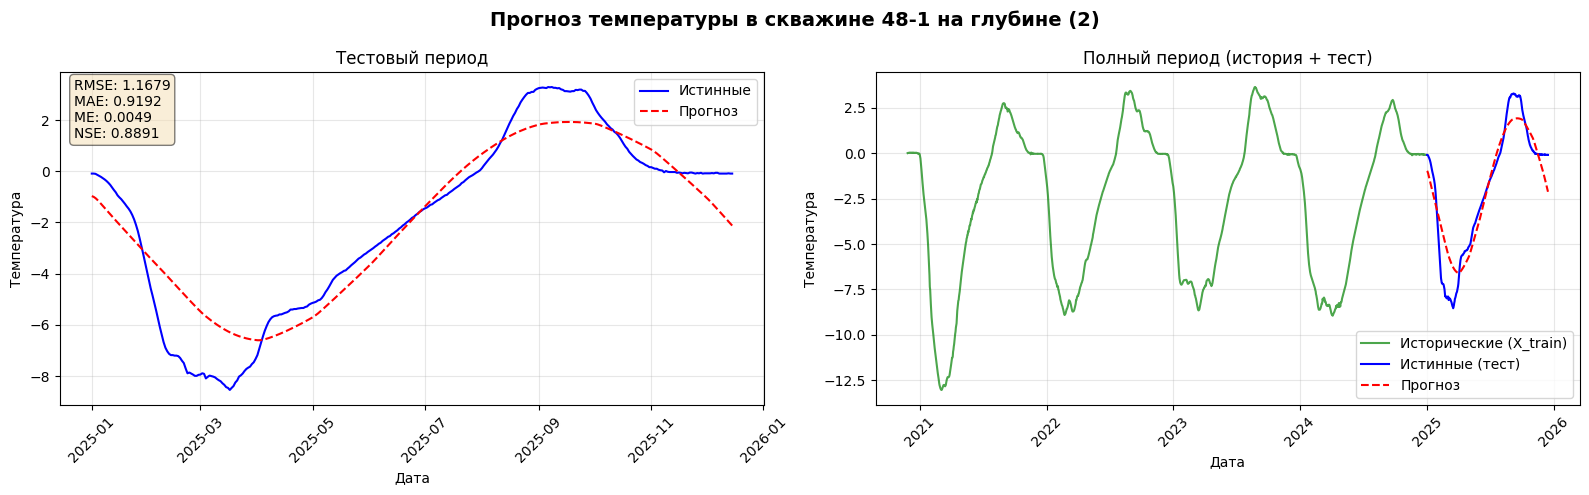

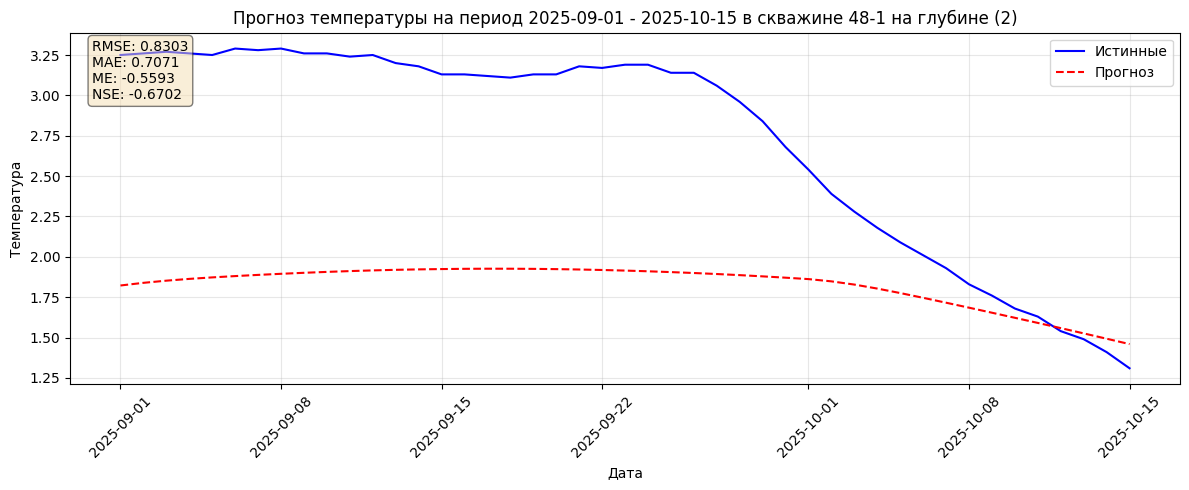

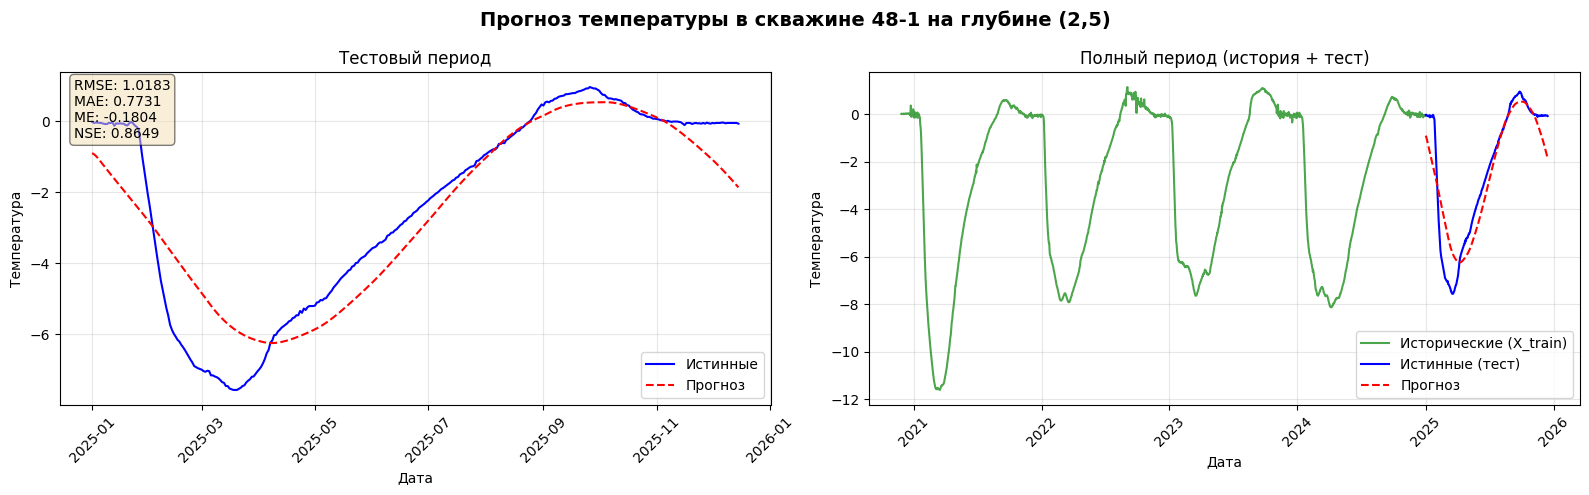

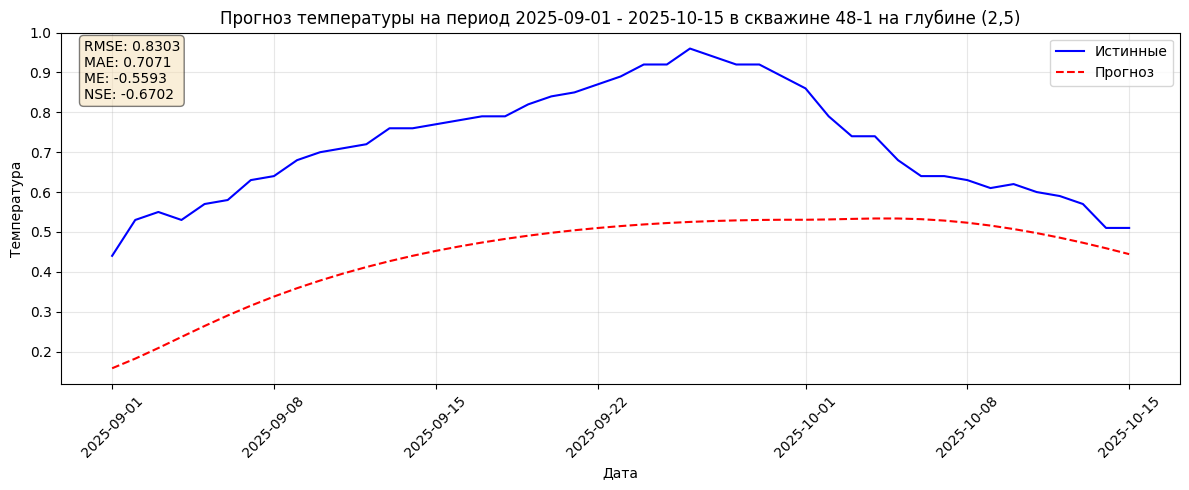

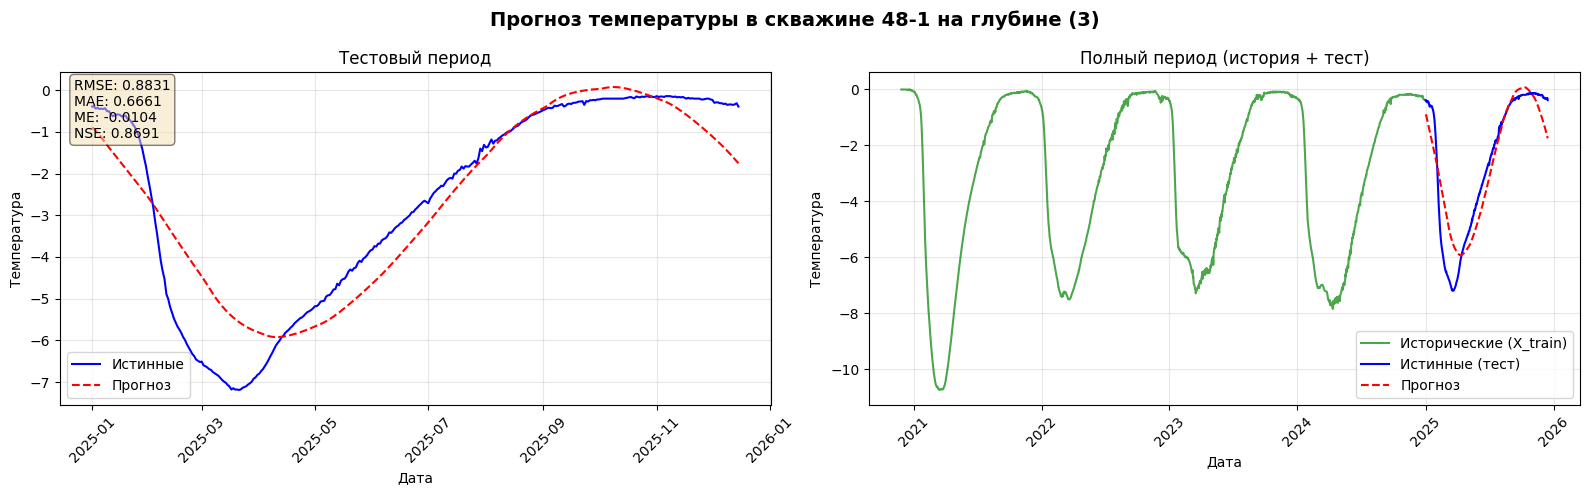

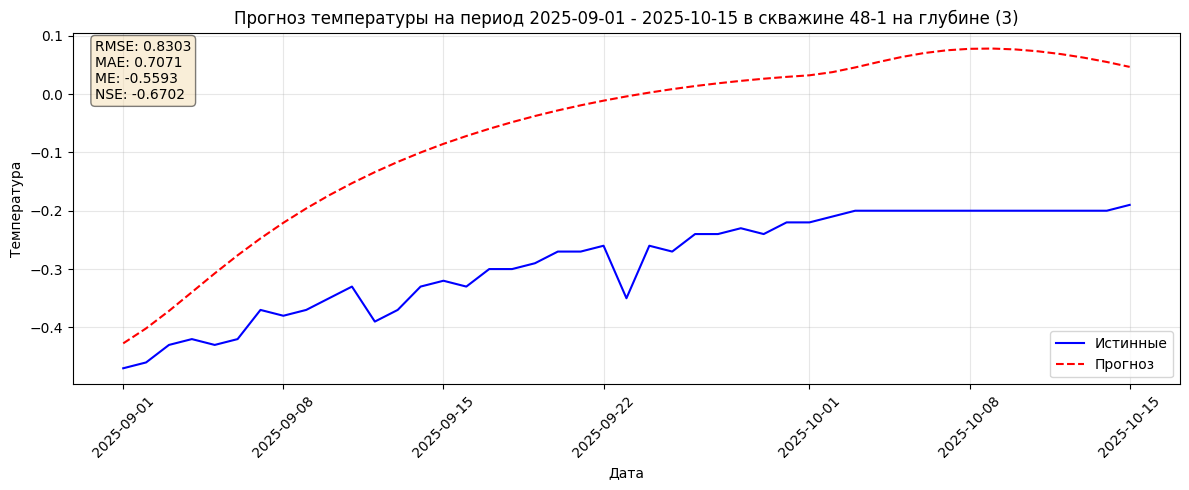

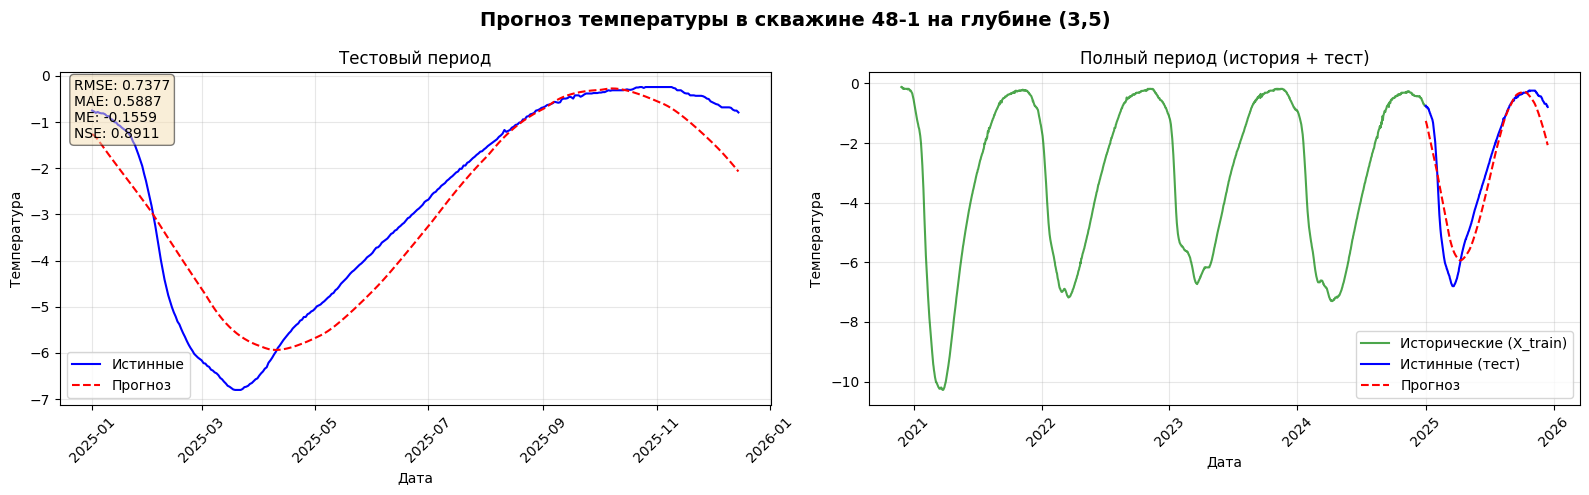

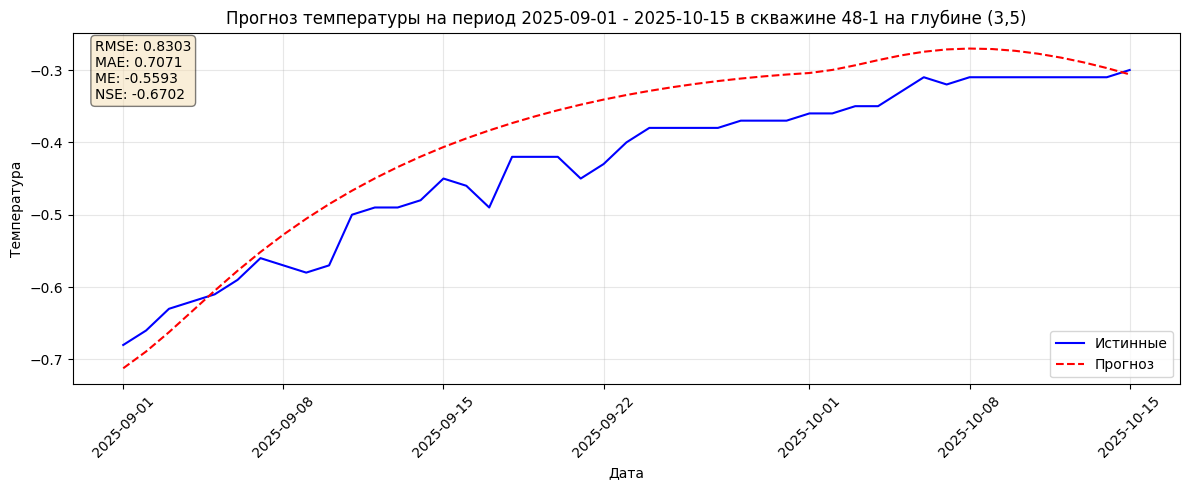

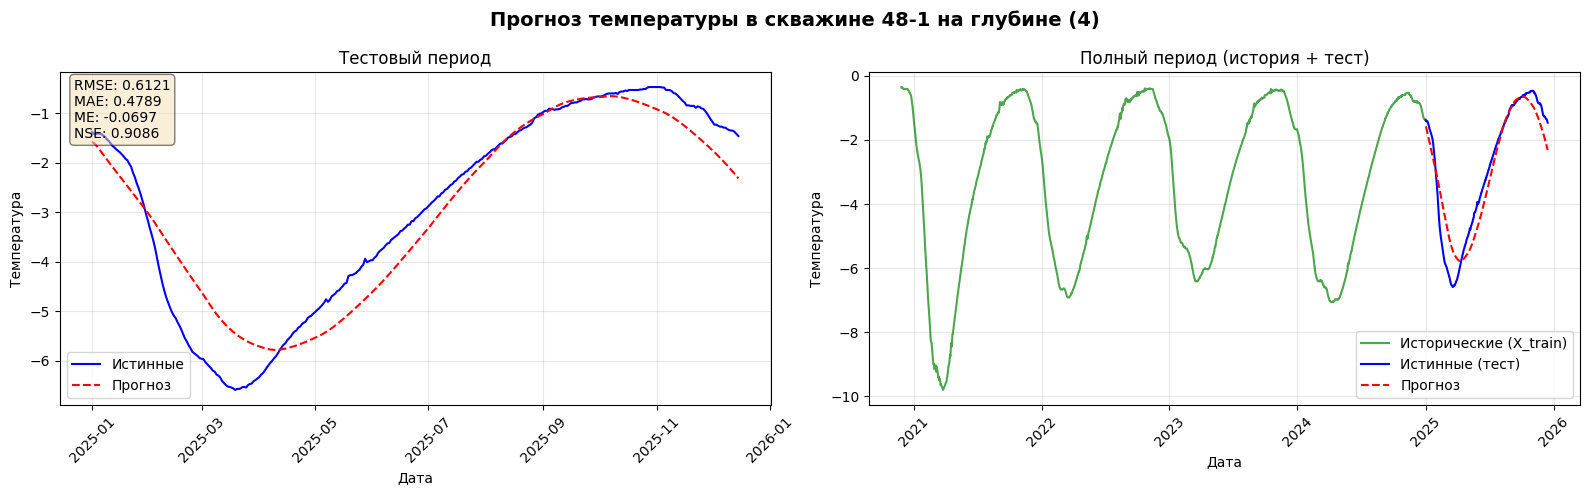

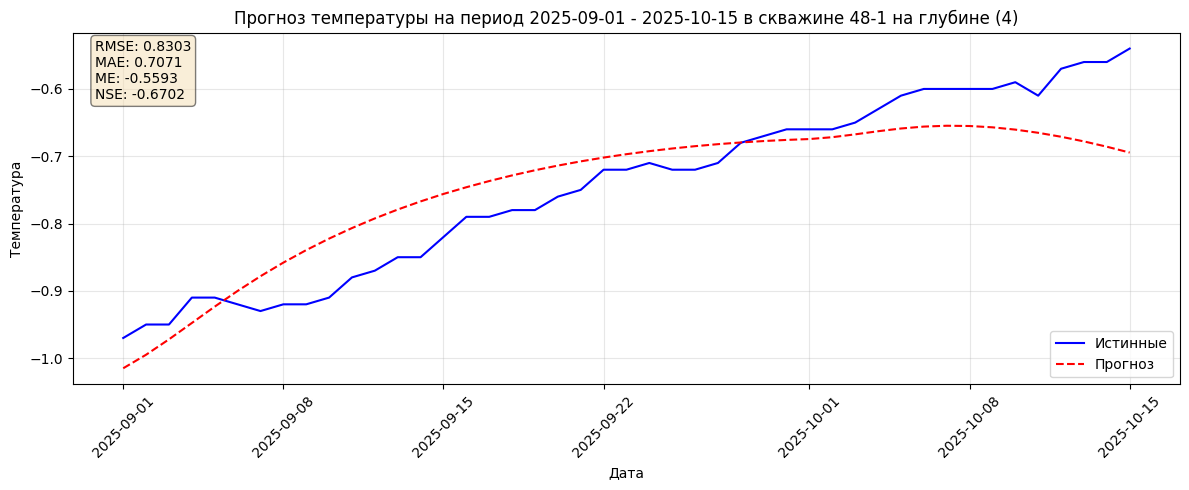

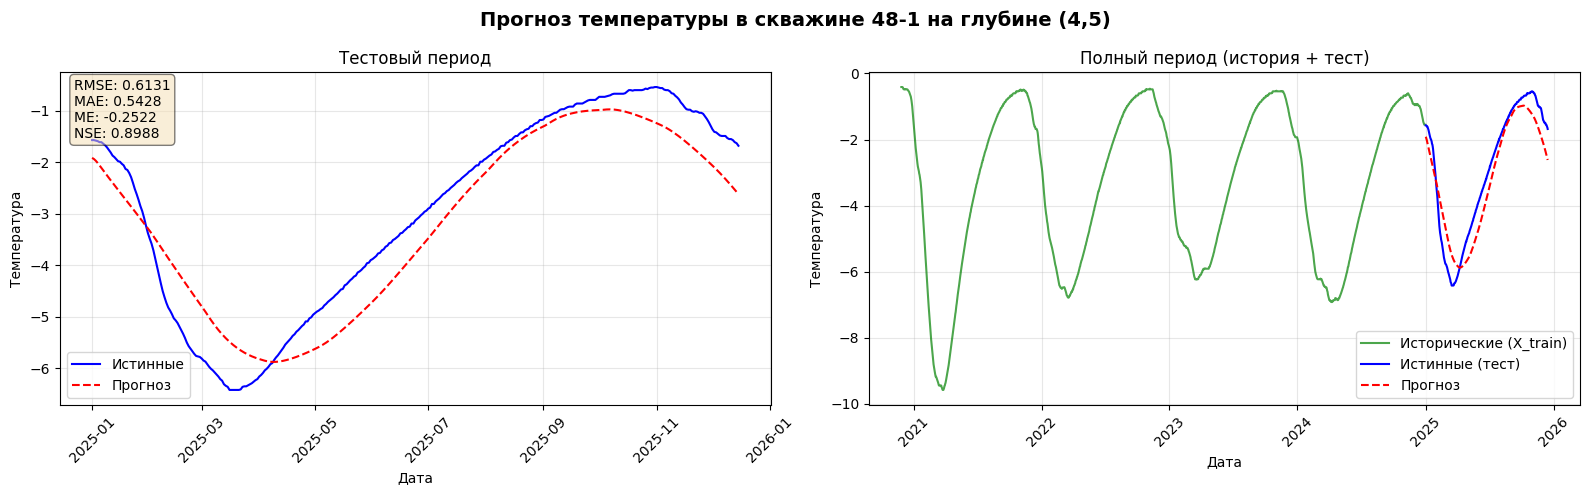

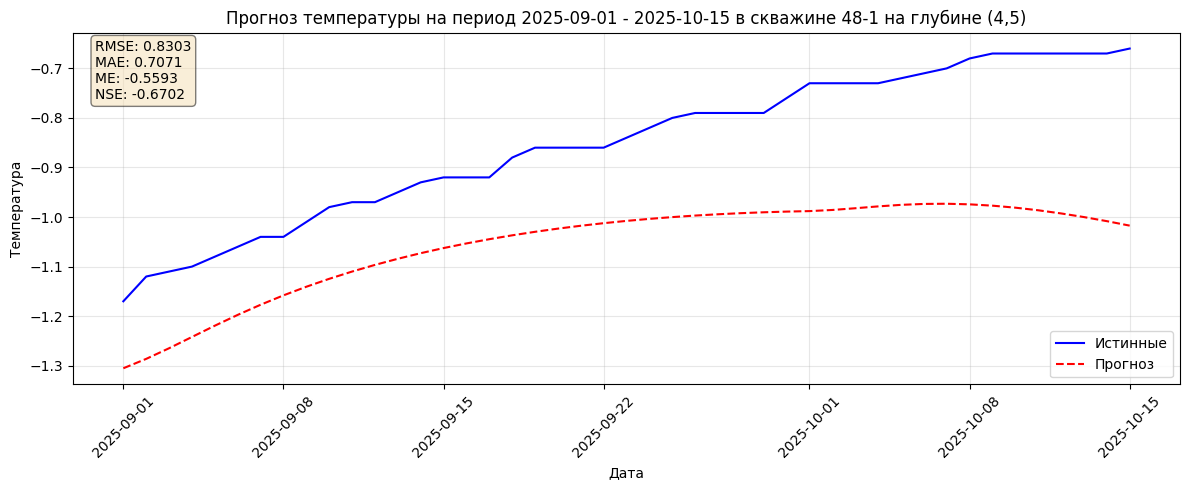

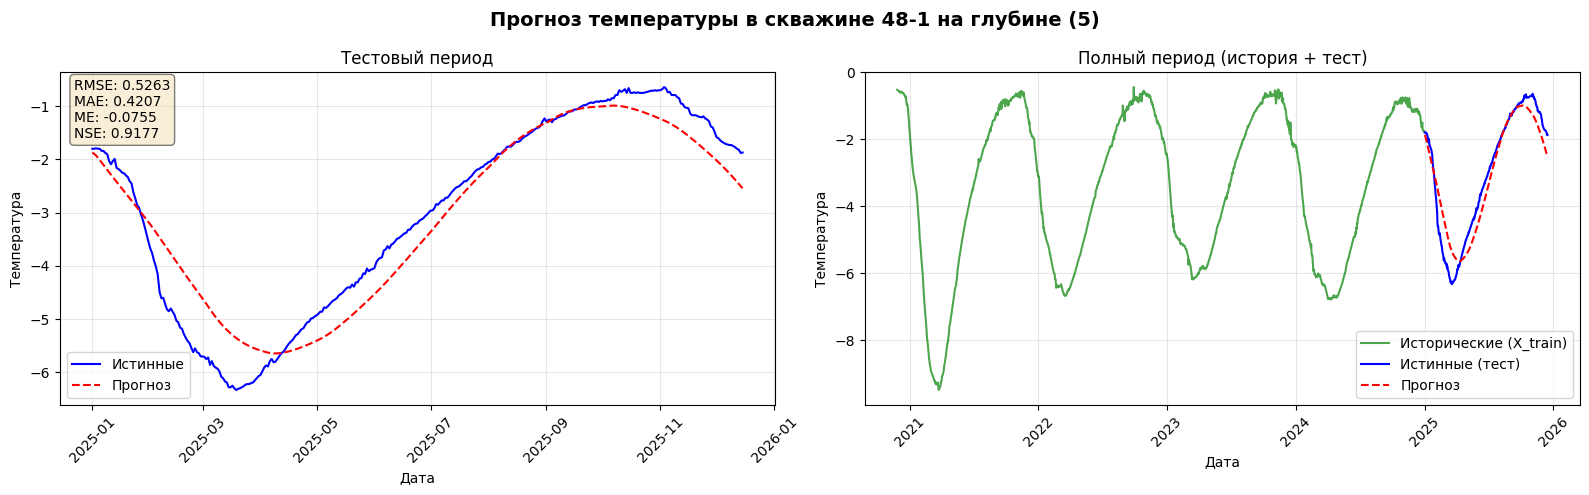

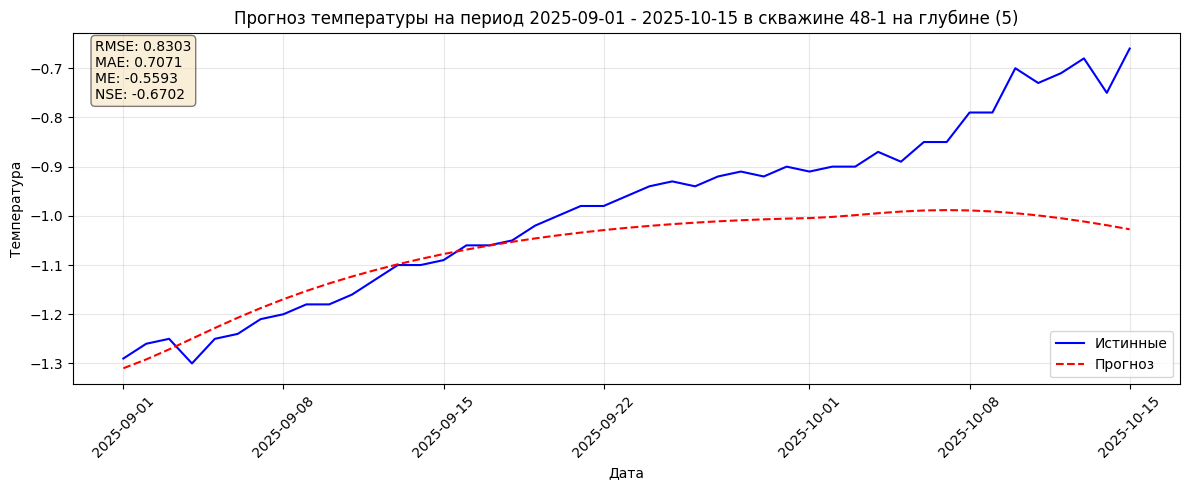

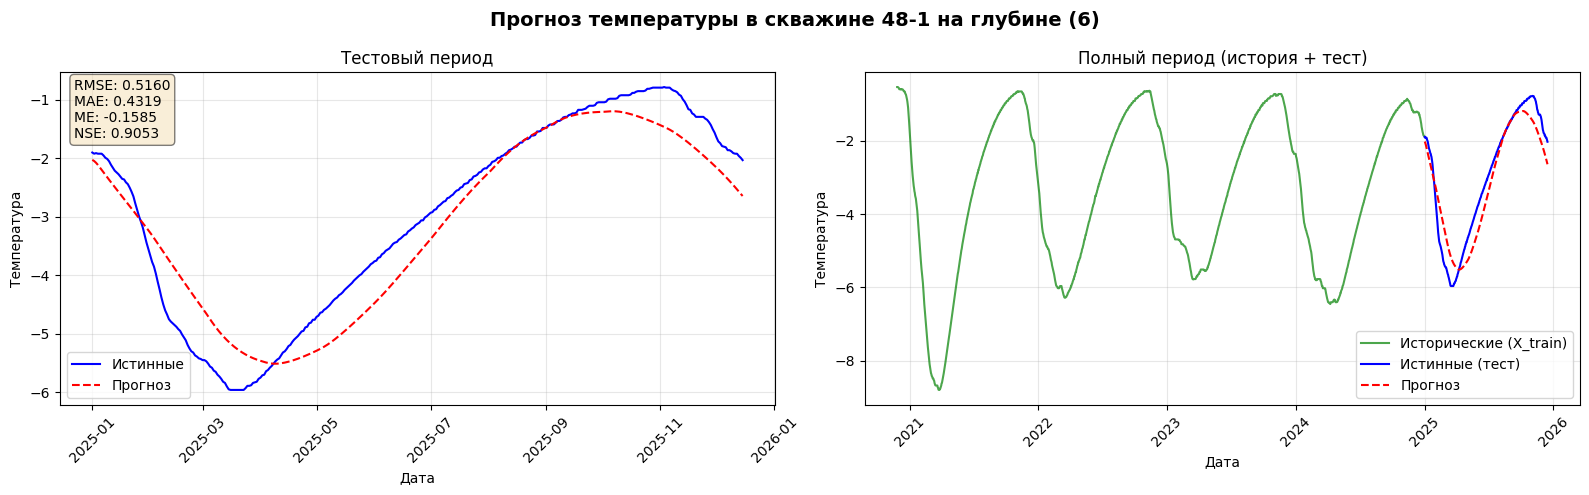

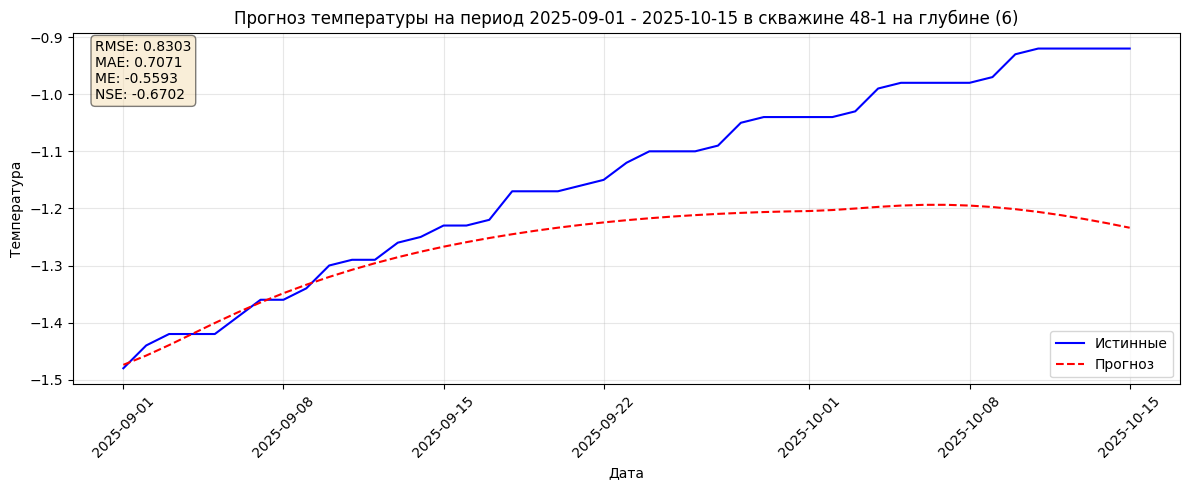

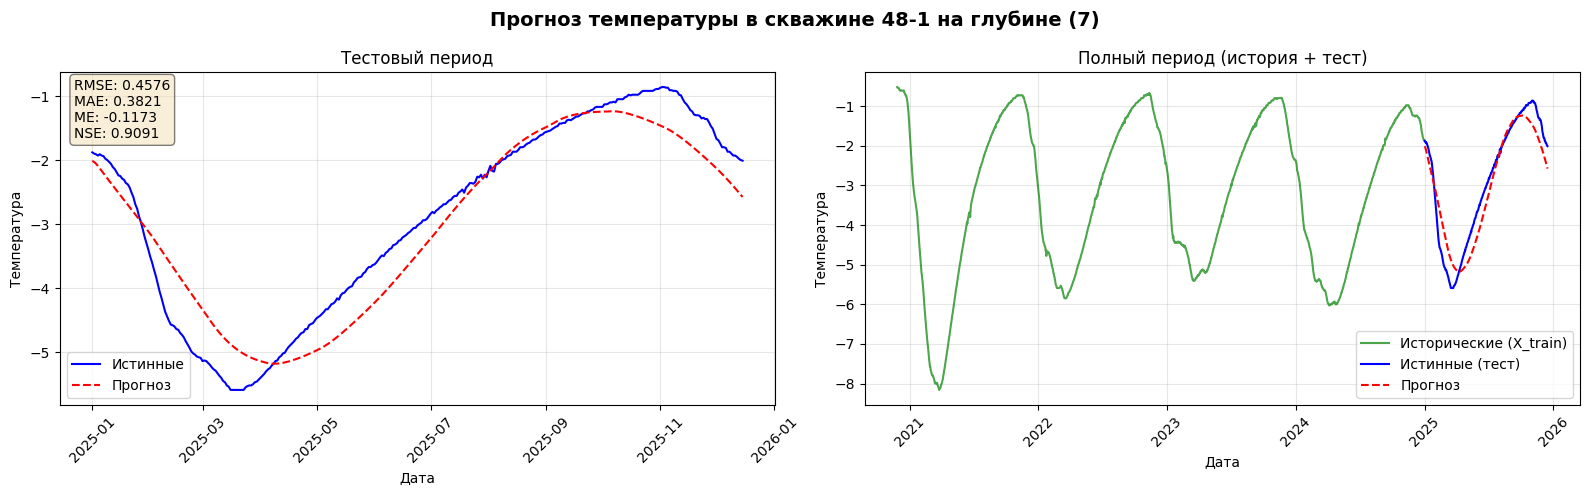

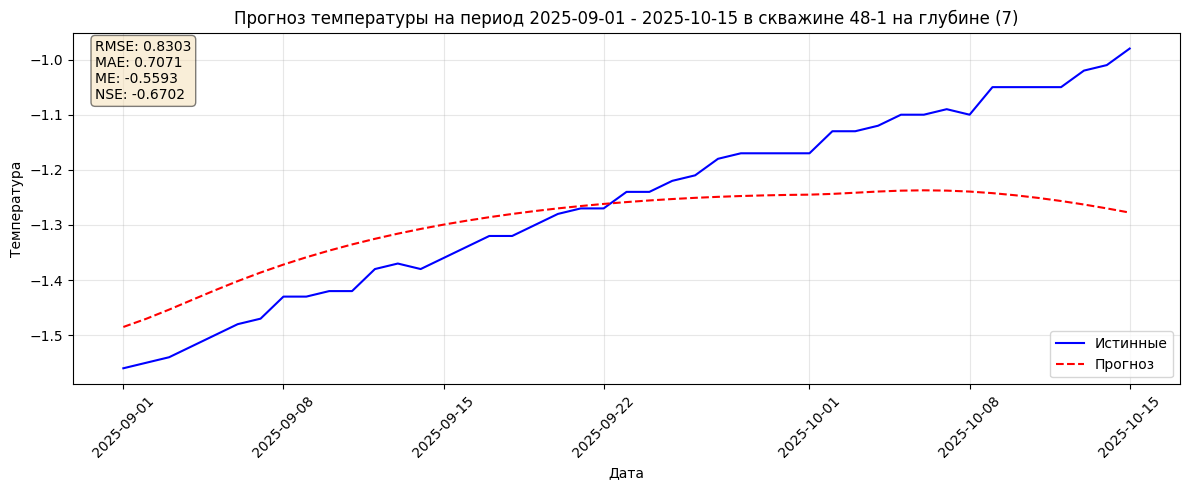

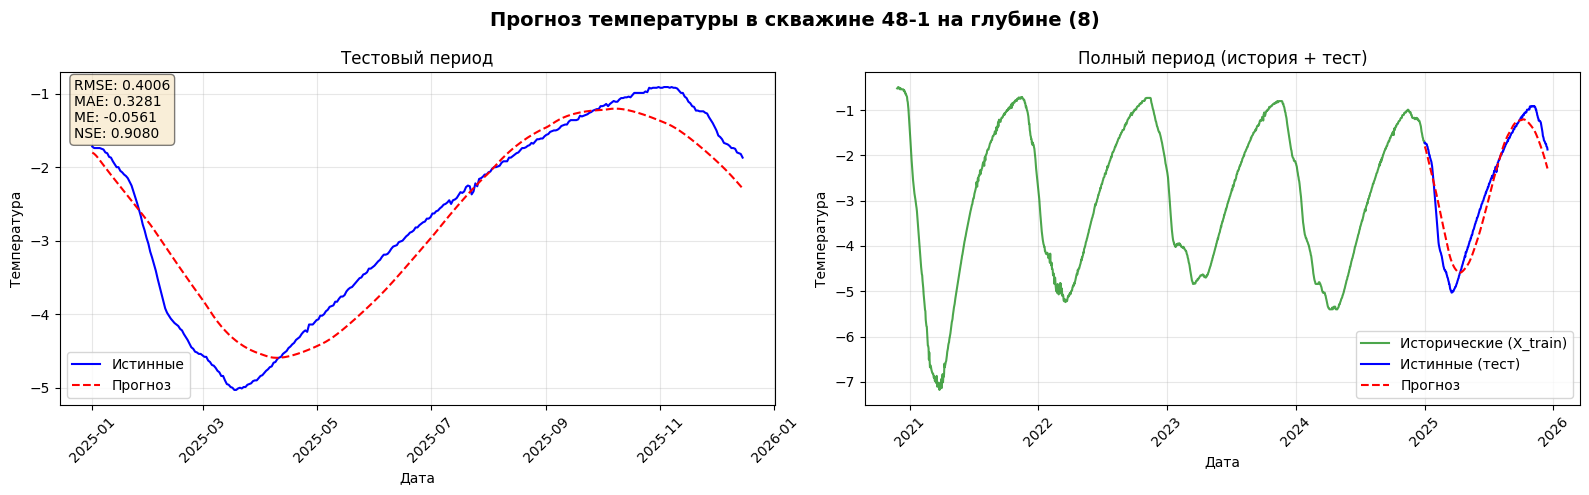

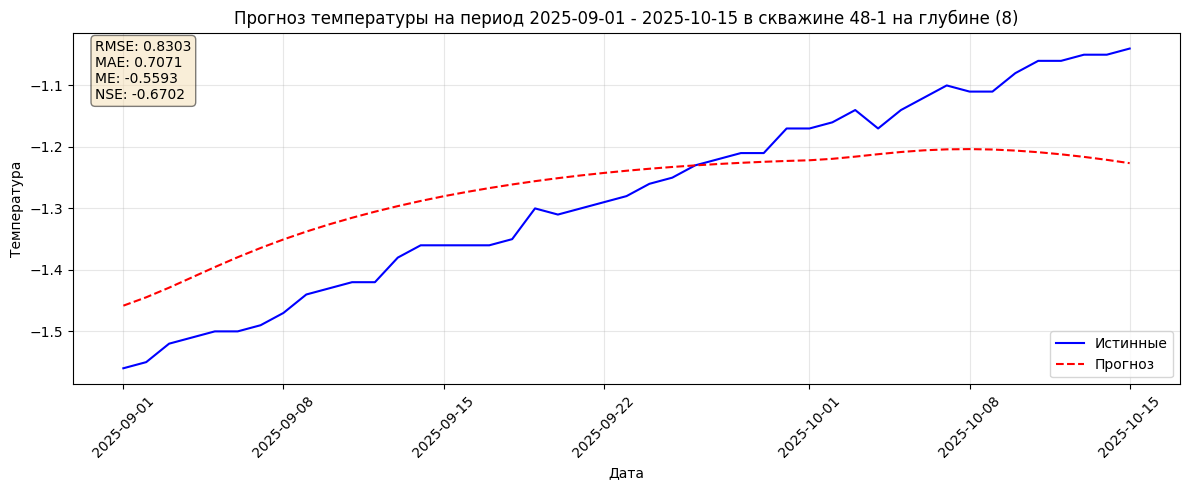

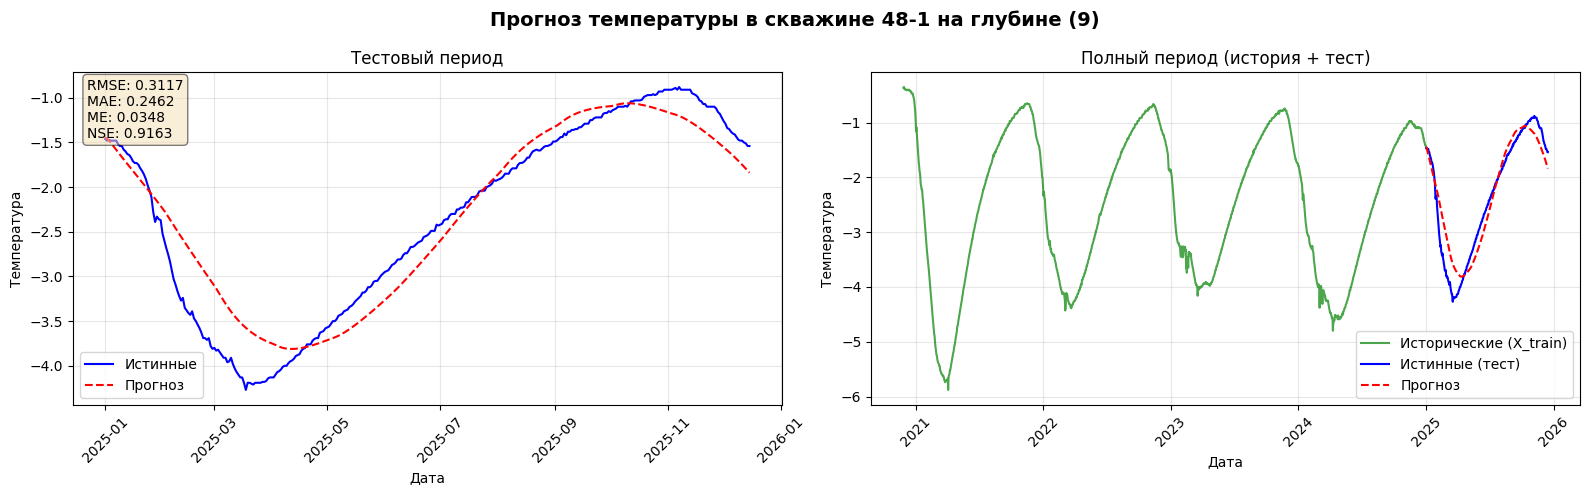

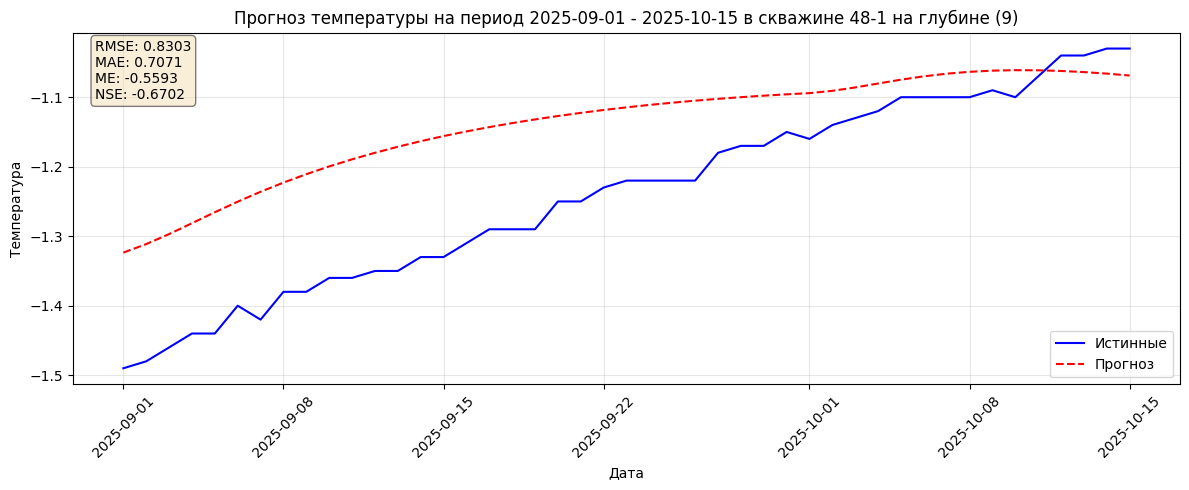

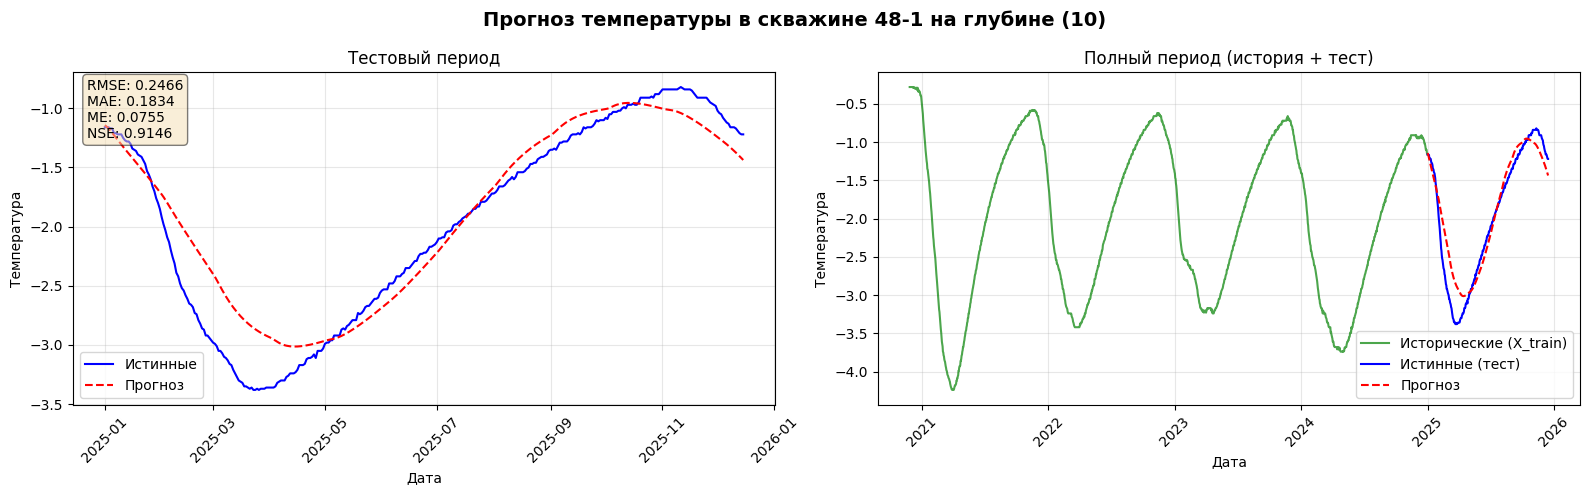

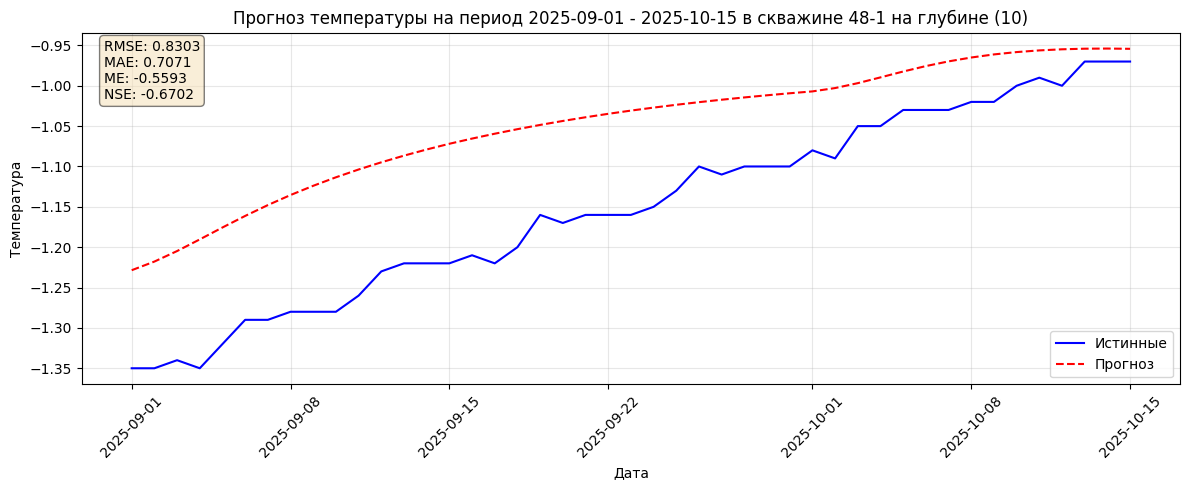

In [12]:
test_start = df_train_full[-lags_length:]

y_pred = predict_recursive(
    model=model,
    df_test=df_test,
    test_start=test_start,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    features_cols=features_cols,
    target_cols=target_cols,
    device=device
)
y_pred = pd.DataFrame(y_pred, columns=target_cols)
y_pred.index = df_test.index
y_true = df_test[target_cols]

evaluate_and_plot_full_forecast(
    y_true=y_true,
    y_pred=y_pred,
    target_cols=target_cols,
    df_train_full=df_train_full,
    required_interval=('2025-09-01', '2025-10-15'),
    borehole_name=borehole_name
)